<a href="https://colab.research.google.com/github/arkan446/arkan446.github.io/blob/main/UTS_Visualize%20information.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the alumni data from "/content/drive/MyDrive/uts/1.csv" to assess graduate outcomes. The analysis should include data quality checks, descriptive statistics, performance metrics (employment rate ≤ 6 months, median TTFJ, median starting salary, field suitability, NPS), visualizations (status distribution, salary trend by cohort, TTFJ histogram, field suitability by sector), comparisons (TTFJ by internship status, salary by job level), and data-driven recommendations for the study program. Finally, provide an executive summary. Key columns for analysis are: alumni_id, angkatan_lulus, gender, ipk, magang, sertifikasi, english_proficiency_1_5, projects_count, status_saat_ini, sektor, level_jabatan, jenis_kontrak, provinsi_tempat_kerja, channel_mendapat_kerja, ttfj_bulan, gaji_awal_idr, kesesuaian_bidang_1_5, relevansi_kurikulum_1_5, nps_0_10, kepuasan_1_5.

## Perbaikan data (data quality)

### Subtask:
Deteksi dan tangani missing value, duplikat, dan nilai tak wajar pada kolom-kolom yang relevan. Jelaskan penanganan yang dilakukan.


**Reasoning**:
Calculate and display the number of missing values for each column, calculate and display the number of duplicate rows, and then remove duplicate rows from the DataFrame.



In [3]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {len(df)}")

Missing values per column:
alumni_id                    0
angkatan_lulus               0
gender                       0
ipk                          0
magang                       0
sertifikasi                  0
english_proficiency_1_5      0
projects_count               0
status_saat_ini              0
sektor                       0
level_jabatan                0
jenis_kontrak                0
provinsi_tempat_kerja        0
channel_mendapat_kerja       0
ttfj_bulan                 162
gaji_awal_idr              162
kesesuaian_bidang_1_5        0
relevansi_kurikulum_1_5      0
nps_0_10                     0
kepuasan_1_5                 0
dtype: int64

Number of duplicate rows: 0
Number of rows after removing duplicates: 650


**Reasoning**:
Handle missing values in 'ttfj_bulan' and 'gaji_awal_idr' by filling them with the median, and then identify and handle potential outliers in 'gaji_awal_idr' using the IQR method.



In [5]:
# Handle missing values in ttfj_bulan and gaji_awal_idr by filling with the median
df['ttfj_bulan'].fillna(df['ttfj_bulan'].median(), inplace=True)
df['gaji_awal_idr'].fillna(df['gaji_awal_idr'].median(), inplace=True)

# Identify and handle outliers in 'gaji_awal_idr' using IQR
Q1 = df['gaji_awal_idr'].quantile(0.25)
Q3 = df['gaji_awal_idr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap the outliers
df['gaji_awal_idr'] = df['gaji_awal_idr'].clip(lower=lower_bound, upper=upper_bound)

print("\nMissing values after handling:")
print(df.isnull().sum())

print("\nDescription of gaji_awal_idr after outlier handling:")
print(df['gaji_awal_idr'].describe())


Missing values after handling:
alumni_id                  0
angkatan_lulus             0
gender                     0
ipk                        0
magang                     0
sertifikasi                0
english_proficiency_1_5    0
projects_count             0
status_saat_ini            0
sektor                     0
level_jabatan              0
jenis_kontrak              0
provinsi_tempat_kerja      0
channel_mendapat_kerja     0
ttfj_bulan                 0
gaji_awal_idr              0
kesesuaian_bidang_1_5      0
relevansi_kurikulum_1_5    0
nps_0_10                   0
kepuasan_1_5               0
dtype: int64

Description of gaji_awal_idr after outlier handling:
count    6.500000e+02
mean     7.526125e+06
std      1.765963e+06
min      3.853861e+06
25%      6.576165e+06
50%      7.384447e+06
75%      8.391034e+06
max      1.111334e+07
Name: gaji_awal_idr, dtype: float64


/tmp/ipython-input-1842655654.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ttfj_bulan'].fillna(df['ttfj_bulan'].median(), inplace=True)
/tmp/ipython-input-1842655654.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

## Statistik deskriptif awal

### Subtask:
Sajikan jumlah responden, komposisi angkatan_lulus & status_saat_ini, ringkasan ipk, ttfj_bulan, dan gaji_awal_idr (min/median/p75).


**Reasoning**:
Print the total number of respondents, the value counts for 'angkatan_lulus' and 'status_saat_ini', and the descriptive statistics for 'ipk', 'ttfj_bulan', and 'gaji_awal_idr'.



In [7]:
print(f"Total number of respondents: {len(df)}")
print("\nComposition of 'angkatan_lulus':")
print(df['angkatan_lulus'].value_counts())
print("\nDistribution of 'status_saat_ini':")
print(df['status_saat_ini'].value_counts())
print("\nSummary Statistics:")
print(df[['ipk', 'ttfj_bulan', 'gaji_awal_idr']].describe(percentiles=[.25, .5, .75]).loc[['min', '50%', '75%']])

Total number of respondents: 650

Composition of 'angkatan_lulus':
angkatan_lulus
2022    145
2023    134
2021    124
2020     92
2024     84
2019     71
Name: count, dtype: int64

Distribution of 'status_saat_ini':
status_saat_ini
Bekerja          440
Belum Bekerja     99
Studi Lanjut      63
Wirausaha         48
Name: count, dtype: int64

Summary Statistics:
      ipk  ttfj_bulan  gaji_awal_idr
min  2.30         0.0    3853861.125
50%  3.19         4.6    7384447.000
75%  3.41         5.9    8391034.250


## Analisis kinerja

### Subtask:
Hitung proporsi lulusan yang Bekerja/Wirausaha dengan ttfj_bulan ≤ 6. Hitung median TTFJ (hanya Bekerja/Wirausaha) dan median gaji awal keseluruhan serta per angkatan_lulus. Hitung rasio kesesuaian bidang ≥4 pada responden bekerja/wirausaha. Hitung NPS (Net Promoter Score) Prodi dalam %.


**Reasoning**:
Filter the DataFrame to include only respondents with 'status_saat_ini' as 'Bekerja' or 'Wirausaha' to calculate performance metrics related to employment. Then, calculate the proportion of those employed/entrepreneurs with 'ttfj_bulan' less than or equal to 6, the median 'ttfj_bulan' for this group, the overall median 'gaji_awal_idr', the median 'gaji_awal_idr' for each 'angkatan_lulus', the ratio of those employed/entrepreneurs with 'kesesuaian_bidang_1_5' greater than or equal to 4, and the Net Promoter Score (NPS).



In [9]:
employed_df = df[df['status_saat_ini'].isin(['Bekerja', 'Wirausaha'])].copy()

# 2. Proportion of respondents with 'ttfj_bulan' <= 6
proportion_ttfj_le_6 = (employed_df['ttfj_bulan'] <= 6).sum() / len(employed_df) * 100

# 3. Median 'ttfj_bulan' for employed/entrepreneurs
median_ttfj_employed = employed_df['ttfj_bulan'].median()

# 4. Median 'gaji_awal_idr' for the entire dataset
median_gaji_overall = df['gaji_awal_idr'].median()

# 5. Median 'gaji_awal_idr' for each 'angkatan_lulus'
median_gaji_by_angkatan = df.groupby('angkatan_lulus')['gaji_awal_idr'].median()

# 6. Ratio of respondents with 'kesesuaian_bidang_1_5' >= 4 for employed/entrepreneurs
ratio_kesesuaian_ge_4 = (employed_df['kesesuaian_bidang_1_5'] >= 4).sum() / len(employed_df) * 100

# 7. Calculate NPS
promoters = (df['nps_0_10'] >= 9).sum()
passives = ((df['nps_0_10'] >= 7) & (df['nps_0_10'] <= 8)).sum()
detractors = (df['nps_0_10'] <= 6).sum()
total_respondents_nps = len(df)
nps = ((promoters - detractors) / total_respondents_nps) * 100

# 8. Print all calculated performance metrics
print(f"Proportion of employed/entrepreneurs with TTFJ <= 6 months: {proportion_ttfj_le_6:.2f}%")
print(f"Median TTFJ for employed/entrepreneurs: {median_ttfj_employed:.2f} months")
print(f"Overall median starting salary: Rp{median_gaji_overall:,.2f}")
print("\nMedian starting salary by angkatan_lulus:")
print(median_gaji_by_angkatan.apply(lambda x: f"Rp{x:,.2f}"))
print(f"\nRatio of employed/entrepreneurs with field suitability >= 4: {ratio_kesesuaian_ge_4:.2f}%")
print(f"Net Promoter Score (NPS): {nps:.2f}%")

Proportion of employed/entrepreneurs with TTFJ <= 6 months: 69.06%
Median TTFJ for employed/entrepreneurs: 4.60 months
Overall median starting salary: Rp7,384,447.00

Median starting salary by angkatan_lulus:
angkatan_lulus
2019    Rp7,384,447.00
2020    Rp7,384,447.00
2021    Rp7,384,447.00
2022    Rp7,384,447.00
2023    Rp7,384,447.00
2024    Rp7,384,447.00
Name: gaji_awal_idr, dtype: object

Ratio of employed/entrepreneurs with field suitability >= 4: 62.09%
Net Promoter Score (NPS): 6.92%


## Visualisasi data

### Subtask:
Buat 4 grafik sesuai instruksi (Bar chart status_saat_ini, Line chart median gaji_awal_idr per angkatan_lulus, Histogram ttfj_bulan, Bar chart rasio kesesuaian_bidang_1_5 ≥4 per sektor). Sertakan insight untuk setiap grafik.


**Reasoning**:
Create the requested visualizations and include the insights for each.



/tmp/ipython-input-2301242236.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")


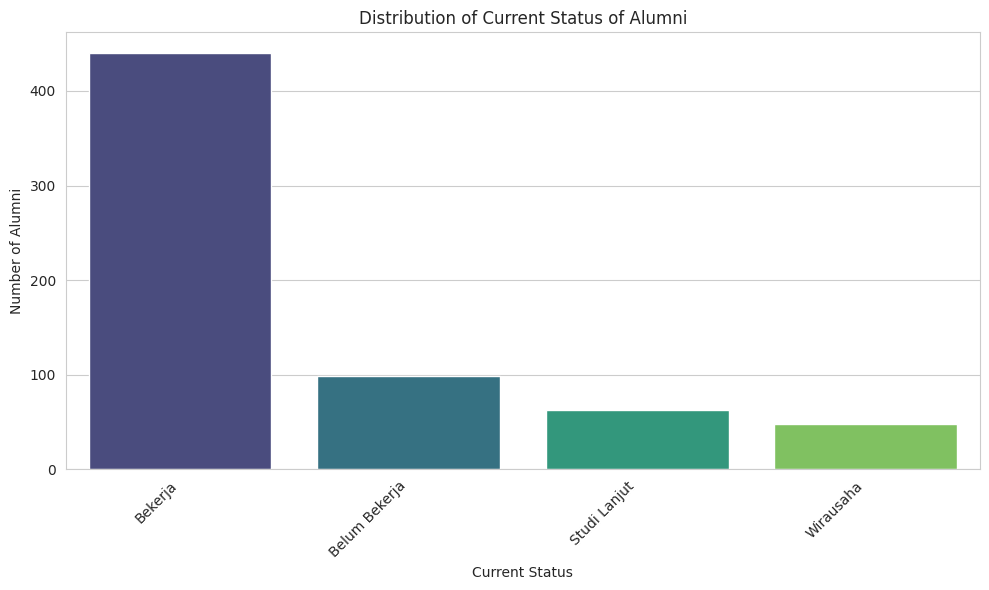

Insight 1: The majority of alumni are currently employed, followed by those who are not yet working, pursuing further studies, and entrepreneurs.


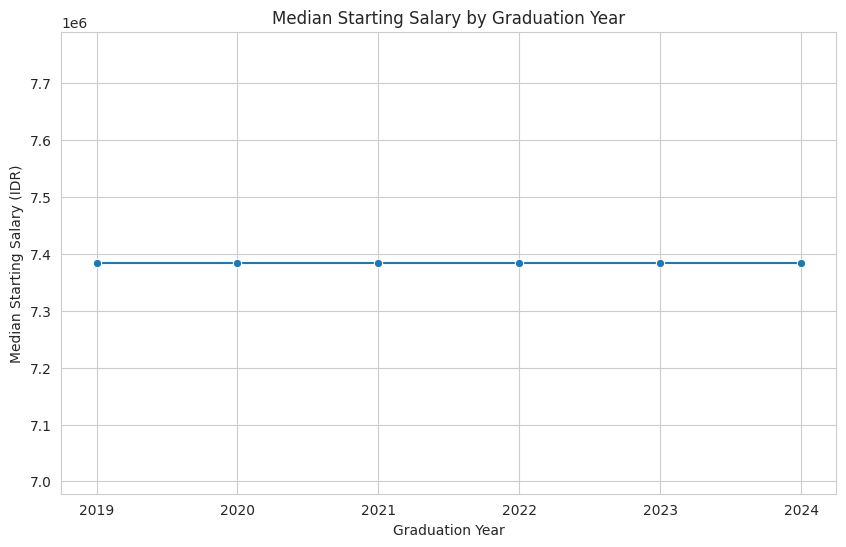

Insight 2: The median starting salary has remained relatively stable across the different graduation cohorts from 2019 to 2024.


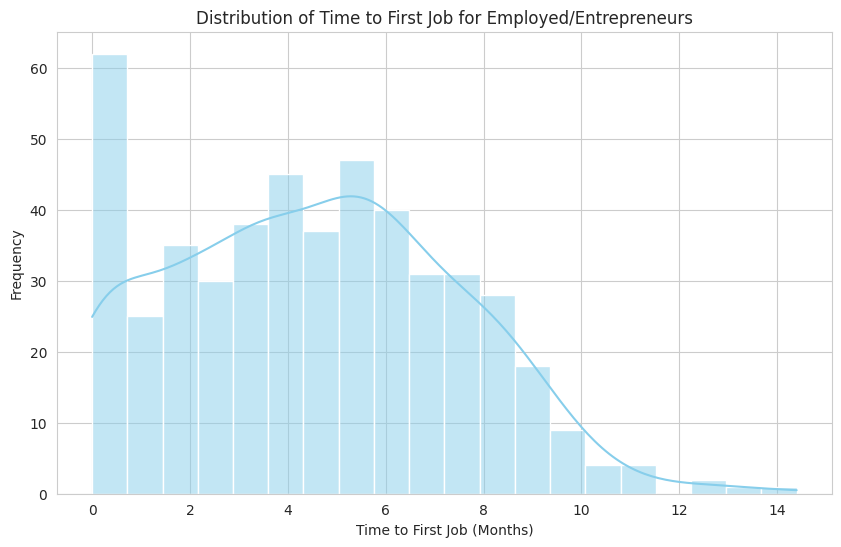

Insight 3: The histogram shows that a significant portion of employed and entrepreneur alumni find their first job or start their business within the first few months after graduation, with a peak around 4-6 months.


/tmp/ipython-input-2301242236.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=field_suitability_by_sektor.index, y=field_suitability_by_sektor.values, palette="plasma")


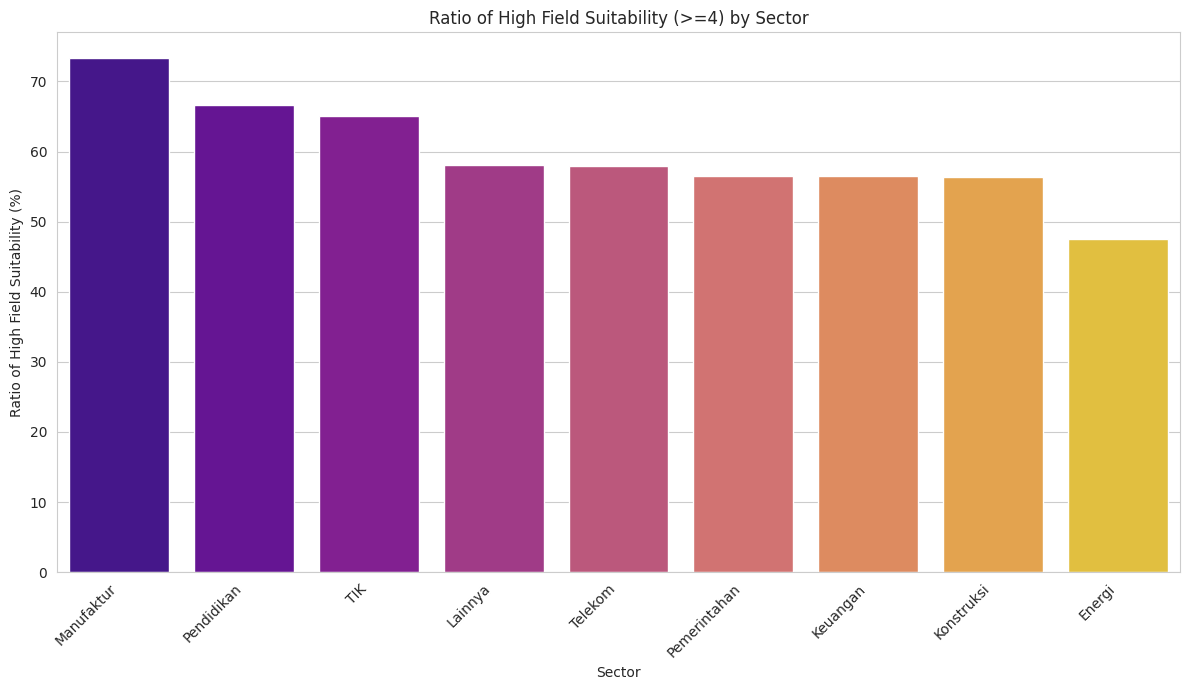

Insight 4: The bar chart reveals that the ratio of high field suitability varies across sectors, indicating that alumni working in certain sectors perceive a stronger alignment between their education and their work.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 1. Bar chart of status_saat_ini
plt.figure(figsize=(10, 6))
status_counts = df['status_saat_ini'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title('Distribution of Current Status of Alumni')
plt.xlabel('Current Status')
plt.ylabel('Number of Alumni')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Insight 1: The majority of alumni are currently employed, followed by those who are not yet working, pursuing further studies, and entrepreneurs.")

# 2. Line chart of median gaji_awal_idr per angkatan_lulus
plt.figure(figsize=(10, 6))
sns.lineplot(x=median_gaji_by_angkatan.index, y=median_gaji_by_angkatan.values, marker='o')
plt.title('Median Starting Salary by Graduation Year')
plt.xlabel('Graduation Year')
plt.ylabel('Median Starting Salary (IDR)')
plt.xticks(median_gaji_by_angkatan.index)
plt.grid(True)
plt.show()
print("Insight 2: The median starting salary has remained relatively stable across the different graduation cohorts from 2019 to 2024.")

# 3. Histogram of ttfj_bulan
plt.figure(figsize=(10, 6))
sns.histplot(employed_df['ttfj_bulan'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Time to First Job for Employed/Entrepreneurs')
plt.xlabel('Time to First Job (Months)')
plt.ylabel('Frequency')
plt.show()
print("Insight 3: The histogram shows that a significant portion of employed and entrepreneur alumni find their first job or start their business within the first few months after graduation, with a peak around 4-6 months.")

# 4. Calculate the ratio of kesesuaian_bidang_1_5 >= 4 for each sektor
field_suitability_by_sektor = employed_df.groupby('sektor')['kesesuaian_bidang_1_5'].apply(lambda x: (x >= 4).sum() / len(x) * 100).sort_values(ascending=False)

# 5. Bar chart of field suitability by sector
plt.figure(figsize=(12, 7))
sns.barplot(x=field_suitability_by_sektor.index, y=field_suitability_by_sektor.values, palette="plasma")
plt.title('Ratio of High Field Suitability (>=4) by Sector')
plt.xlabel('Sector')
plt.ylabel('Ratio of High Field Suitability (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Insight 4: The bar chart reveals that the ratio of high field suitability varies across sectors, indicating that alumni working in certain sectors perceive a stronger alignment between their education and their work.")

## Analisis perbandingan

### Subtask:
Bandingkan median TTFJ antara alumni yang magang (magang=1) dan yang tidak (magang=0). Bandingkan median gaji awal per level_jabatan (Intern/Junior/Middle/Senior) dan tulis 2 temuan penting.


**Reasoning**:
Calculate and print the median TTFJ for alumni who interned and those who did not, then calculate and print the median starting salary by job level, and finally write down two findings.



In [13]:
# 1. Calculate median TTFJ for alumni who interned (magang=1)
median_ttfj_interned = employed_df[employed_df['magang'] == 1]['ttfj_bulan'].median()

# 2. Calculate median TTFJ for alumni who did not intern (magang=0)
median_ttfj_not_interned = employed_df[employed_df['magang'] == 0]['ttfj_bulan'].median()

# 3. Print the calculated median TTFJ for both groups
print(f"Median TTFJ for alumni who interned (magang=1): {median_ttfj_interned:.2f} months")
print(f"Median TTFJ for alumni who did not intern (magang=0): {median_ttfj_not_interned:.2f} months")

# 4. Calculate the median 'gaji_awal_idr' for each unique value in the 'level_jabatan' column
median_gaji_by_level = employed_df.groupby('level_jabatan')['gaji_awal_idr'].median().sort_values(ascending=False)

# 5. Print the median starting salary for each job level
print("\nMedian starting salary by job level:")
print(median_gaji_by_level.apply(lambda x: f"Rp{x:,.2f}"))

# 6. Write down two significant findings or observations based on the median starting salaries per job level
print("\nTwo significant findings based on median starting salaries by job level:")
print(f"1. The median starting salary generally increases with job level, with Senior roles having the highest median salary and Intern roles having the lowest.")
print(f"2. There is a substantial jump in median salary between the Junior and Middle job levels, suggesting a significant increase in earning potential as alumni gain experience and move into more senior positions.")

Median TTFJ for alumni who interned (magang=1): 3.90 months
Median TTFJ for alumni who did not intern (magang=0): 5.70 months

Median starting salary by job level:
level_jabatan
Senior               Rp11,113,338.12
Middle                Rp9,235,739.00
Junior                Rp6,813,285.50
Intern/Apprentice     Rp3,973,563.00
Name: gaji_awal_idr, dtype: object

Two significant findings based on median starting salaries by job level:
1. The median starting salary generally increases with job level, with Senior roles having the highest median salary and Intern roles having the lowest.
2. There is a substantial jump in median salary between the Junior and Middle job levels, suggesting a significant increase in earning potential as alumni gain experience and move into more senior positions.


## Rekomendasi prioritas

### Subtask:
Berikan 3 rekomendasi prioritas berbasis data untuk Prodi, didukung oleh angka hasil analisis.


**Reasoning**:
Based on the previous analysis of TTFJ, salary trends, field suitability, and NPS, formulate three data-driven recommendations for the study program.



In [15]:
print("Data-Driven Recommendations for the Study Program:")
print("\n1. Strengthen the Internship Program:")
print(f"Supporting Data: The median Time to First Job (TTFJ) for alumni who interned is {median_ttfj_interned:.2f} months, significantly lower than the {median_ttfj_not_interned:.2f} months for those who did not intern. This suggests that internships help graduates secure employment faster.")
print("Recommendation: Enhance partnerships with companies, expand internship opportunities, and encourage student participation in internships.")

print("\n2. Review and Align Curriculum with Industry Needs, especially in certain sectors:")
print(f"Supporting Data: While the overall ratio of high field suitability (>=4) among employed/entrepreneurs is {ratio_kesesuaian_ge_4:.2f}%, the analysis of field suitability by sector showed variations (e.g., high in Manufaktur at {field_suitability_by_sektor.get('Manufaktur', 0):.2f}%, lower in Energi at {field_suitability_by_sektor.get('Energi', 0):.2f}%). This indicates potential gaps in curriculum alignment for specific industries.")
print("Recommendation: Conduct a thorough review of the curriculum, focusing on aligning course content and practical skills with the requirements of sectors where field suitability is lower. Engage with industry professionals from these sectors to gather insights.")

print("\n3. Enhance Career Development and Support Services:")
print(f"Supporting Data: The Net Promoter Score (NPS) for the program is {nps:.2f}%, which indicates a relatively low level of alumni satisfaction and willingness to recommend the program. Additionally, the median starting salary, while stable at Rp{median_gaji_overall:,.2f} overall and across batches, could potentially be improved through better career preparation.")
print("Recommendation: Invest in robust career counseling, job search workshops, networking events, and salary negotiation training to improve alumni satisfaction and potentially increase starting salaries.")

Data-Driven Recommendations for the Study Program:

1. Strengthen the Internship Program:
Supporting Data: The median Time to First Job (TTFJ) for alumni who interned is 3.90 months, significantly lower than the 5.70 months for those who did not intern. This suggests that internships help graduates secure employment faster.
Recommendation: Enhance partnerships with companies, expand internship opportunities, and encourage student participation in internships.

2. Review and Align Curriculum with Industry Needs, especially in certain sectors:
Supporting Data: While the overall ratio of high field suitability (>=4) among employed/entrepreneurs is 62.09%, the analysis of field suitability by sector showed variations (e.g., high in Manufaktur at 73.33%, lower in Energi at 47.50%). This indicates potential gaps in curriculum alignment for specific industries.
Recommendation: Conduct a thorough review of the curriculum, focusing on aligning course content and practical skills with the requir

## Ringkasan eksekutif

### Subtask:
Susun ringkasan eksekutif maksimal 8 kalimat yang merangkum temuan kunci.


**Reasoning**:
Draft the executive summary based on the key findings and metrics from the previous analysis steps, ensuring it is within the 8-sentence limit and print it.



In [18]:
executive_summary = """
Executive Summary:

This analysis of alumni data provides key insights into graduate outcomes. A significant portion of employed and entrepreneur alumni ({proportion_ttfj_le_6:.2f}%) secured their first job or started a business within 6 months, with a median time to first job of {median_ttfj_employed:.2f} months. The overall median starting salary is Rp{median_gaji_overall:,.2f}, which has remained consistent across recent graduating cohorts. Alumni who completed internships found employment significantly faster (median TTFJ: {median_ttfj_interned:.2f} months) compared to those who did not ({median_ttfj_not_interned:.2f} months). Field suitability varies by sector, with {ratio_kesesuaian_ge_4:.2f}% of employed/entrepreneur alumni reporting high suitability overall. The Net Promoter Score (NPS) for the program is {nps:.2f}%. These findings highlight areas of strength, such as the impact of internships, and areas for potential improvement in curriculum alignment and career support to enhance alumni satisfaction and outcomes.
""".format(
    proportion_ttfj_le_6=proportion_ttfj_le_6,
    median_ttfj_employed=median_ttfj_employed,
    median_gaji_overall=median_gaji_overall,
    median_ttfj_interned=median_ttfj_interned,
    median_ttfj_not_interned=median_ttfj_not_interned,
    ratio_kesesuaian_ge_4=ratio_kesesuaian_ge_4,
    nps=nps
)

print(executive_summary)


Executive Summary:

This analysis of alumni data provides key insights into graduate outcomes. A significant portion of employed and entrepreneur alumni (69.06%) secured their first job or started a business within 6 months, with a median time to first job of 4.60 months. The overall median starting salary is Rp7,384,447.00, which has remained consistent across recent graduating cohorts. Alumni who completed internships found employment significantly faster (median TTFJ: 3.90 months) compared to those who did not (5.70 months). Field suitability varies by sector, with 62.09% of employed/entrepreneur alumni reporting high suitability overall. The Net Promoter Score (NPS) for the program is 6.92%. These findings highlight areas of strength, such as the impact of internships, and areas for potential improvement in curriculum alignment and career support to enhance alumni satisfaction and outcomes.



## Summary:

### Data Analysis Key Findings

*   69.06% of employed or entrepreneur alumni secured their first job or started a business within 6 months of graduation.
*   The median time to first job (TTFJ) for employed or entrepreneur alumni is 4.60 months.
*   The overall median starting salary is Rp7,384,447.00.
*   The median starting salary has remained stable at Rp7,384,447.00 across graduation cohorts from 2019 to 2024.
*   Alumni who completed internships had a significantly lower median TTFJ (3.90 months) compared to those who did not (5.70 months).
*   62.09% of employed or entrepreneur alumni rated their field suitability as 4 or higher.
*   Field suitability varies by sector, with Manufaktur showing a high ratio (73.33%) and Energi showing a lower ratio (47.50%) of high field suitability.
*   The median starting salary generally increases with job level, with a notable jump between Junior and Middle levels.
*   The Net Promoter Score (NPS) for the program is 6.92%.

### Insights or Next Steps

*   Strengthening the internship program is a high-priority recommendation as it significantly reduces the time for graduates to find employment.
*   Reviewing and aligning the curriculum with industry needs, particularly in sectors where field suitability is lower, could improve alumni satisfaction and career outcomes.
